# IPL Processed Data EDA

This notebook analyzes the processed live-state training table in `data/processed/ipl_features.csv`.

It includes:
- dataset shape and schema
- missing-value checks
- season, team, venue, innings, and phase coverage
- target and feature distributions
- stronger win-rate views by phase, team, and venue


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('ggplot')
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 200)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')


In [2]:
ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
DATA_DIR = ROOT / 'data'
PROCESSED_DIR = DATA_DIR / 'processed'
RAW_DIR = DATA_DIR / 'ipl_csv2'
FEATURES_PATH = PROCESSED_DIR / 'ipl_features.csv'

df = pd.read_csv(FEATURES_PATH, low_memory=False)
df['season'] = df['season'].astype(str)
df['start_date'] = pd.to_datetime(df['start_date'], errors='coerce')
win_df = df[df['win'].notna()].copy()

raw_match_files = sorted([p for p in RAW_DIR.glob('*.csv') if not p.name.endswith('_info.csv')])
support_tables = sorted([p.name for p in PROCESSED_DIR.glob('*') if p.is_file() and p.name != 'ipl_features.csv'])

print('features path:', FEATURES_PATH)
print('rows:', len(df))
print('matches:', df['match_id'].nunique())
print('raw match files:', len(raw_match_files))
print('support tables:', support_tables)


features path: C:\Users\rahul\Documents\code\projects\ipl prediction\data\processed\ipl_features.csv
rows: 278705
matches: 1172
raw match files: 1172
support tables: ['active_teams_2026.csv', 'batter_bowler_form_latest.csv', 'batter_form_latest.csv', 'bowler_form_latest.csv', 'live_weather_snapshot.json', 'matchup_form_latest.csv', 'team_form_latest.csv', 'team_player_pool_2026.csv', 'team_venue_form_latest.csv', 'venue_stats.csv']


## Overview

In [3]:
overview = pd.Series({
    'rows': len(df),
    'columns': len(df.columns),
    'matches': df['match_id'].nunique(),
    'seasons': df['season'].nunique(),
    'teams': df['batting_team'].nunique(),
    'venues': df['venue'].nunique(),
    'date_min': df['start_date'].min(),
    'date_max': df['start_date'].max(),
    'first_innings_rows': int((df['innings'] == 1).sum()),
    'second_innings_rows': int((df['innings'] == 2).sum()),
    'non_null_win_rows': len(win_df),
})
overview

rows                                278705
columns                                 60
matches                               1172
seasons                                 19
teams                                   15
venues                                  41
date_min               2008-04-18 00:00:00
date_max               2026-03-30 00:00:00
first_innings_rows                  144508
second_innings_rows                 134197
non_null_win_rows                   274174
dtype: object

In [4]:
df.head()

,match_id,season,start_date,venue,innings,ball,batting_team,bowling_team,striker,non_striker,bowler,toss_winner,toss_decision,toss_winner_batting,runs,wickets,wickets_left,balls_left,legal_balls_bowled,innings_progress,over_number,ball_in_over,phase,is_powerplay,is_middle,is_death,runs_last_5,wickets_last_5,runs_last_6_balls,wickets_last_6_balls,runs_last_12_balls,wickets_last_12_balls,current_run_rate,target,target_remaining,required_run_rate,current_minus_required_rr,required_minus_current_rr,batting_team_form,bowling_team_form,batting_team_venue_form,bowling_team_venue_form,batting_vs_bowling_form,striker_form_sr,striker_form_avg,bowler_form_econ,bowler_form_strike,batter_vs_bowler_sr,batter_vs_bowler_balls,temperature_c,relative_humidity,wind_kph,dew_risk,runs_vs_par,venue_avg_first_innings,venue_avg_second_innings,venue_bat_first_win_rate,total_runs,winner,win
0,335982,2007/08,2008-04-18,M. Chinnaswamy Stadium,1,0.100,Kolkata Knight Riders,Royal Challengers Bengaluru,SC Ganguly,BB McCullum,P Kumar,Royal Challengers Bengaluru,field,0,1.000,0,10,119,1,0.008,0.000,1.000,powerplay,1.000,0.000,0.000,1.000,0,1.000,0,1.000,0,6.000,NaN,NaN,NaN,NaN,NaN,0.500,0.500,0.500,0.500,0.500,0.000,0.000,0.000,0.000,0.000,0.000,28.000,60.000,12.000,0.500,1.000,0.000,0.000,0.000,222,Kolkata Knight Riders,1.000
1,335982,2007/08,2008-04-18,M. Chinnaswamy Stadium,1,0.200,Kolkata Knight Riders,Royal Challengers Bengaluru,BB McCullum,SC Ganguly,P Kumar,Royal Challengers Bengaluru,field,0,1.000,0,10,118,2,0.017,0.000,2.000,powerplay,1.000,0.000,0.000,1.000,0,1.000,0,1.000,0,3.000,NaN,NaN,NaN,NaN,NaN,0.500,0.500,0.500,0.500,0.500,0.000,0.000,6.000,1.000,0.000,0.000,28.000,60.000,12.000,0.500,1.000,0.000,0.000,0.000,222,Kolkata Knight Riders,1.000
2,335982,2007/08,2008-04-18,M. Chinnaswamy Stadium,1,0.300,Kolkata Knight Riders,Royal Challengers Bengaluru,BB McCullum,SC Ganguly,P Kumar,Royal Challengers Bengaluru,field,0,2.000,0,10,118,2,0.017,0.000,2.000,powerplay,1.000,0.000,0.000,2.000,0,1.000,0,1.000,0,6.000,NaN,NaN,NaN,NaN,NaN,0.500,0.500,0.500,0.500,0.500,0.000,0.000,3.000,2.000,0.000,1.000,28.000,60.000,12.000,0.500,2.000,0.000,0.000,0.000,222,Kolkata Knight Riders,1.000
3,335982,2007/08,2008-04-18,M. Chinnaswamy Stadium,1,0.400,Kolkata Knight Riders,Royal Challengers Bengaluru,BB McCullum,SC Ganguly,P Kumar,Royal Challengers Bengaluru,field,0,2.000,0,10,117,3,0.025,0.000,3.000,powerplay,1.000,0.000,0.000,2.000,0,1.000,0,1.000,0,4.000,NaN,NaN,NaN,NaN,NaN,0.500,0.500,0.500,0.500,0.500,0.000,0.000,6.000,2.000,0.000,1.000,28.000,60.000,12.000,0.500,2.000,0.000,0.000,0.000,222,Kolkata Knight Riders,1.000
4,335982,2007/08,2008-04-18,M. Chinnaswamy Stadium,1,0.500,Kolkata Knight Riders,Royal Challengers Bengaluru,BB McCullum,SC Ganguly,P Kumar,Royal Challengers Bengaluru,field,0,2.000,0,10,116,4,0.033,0.000,4.000,powerplay,1.000,0.000,0.000,2.000,0,1.000,0,1.000,0,3.000,NaN,NaN,NaN,NaN,NaN,0.500,0.500,0.500,0.500,0.500,0.000,0.000,4.000,3.000,0.000,2.000,28.000,60.000,12.000,0.500,2.000,0.000,0.000,0.000,222,Kolkata Knight Riders,1.000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 278705 entries, 0 to 278704
Data columns (total 60 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   match_id                   278705 non-null  int64         
 1   season                     278705 non-null  object        
 2   start_date                 278705 non-null  datetime64[ns]
 3   venue                      278705 non-null  object        
 4   innings                    278705 non-null  int64         
 5   ball                       278705 non-null  float64       
 6   batting_team               278705 non-null  object        
 7   bowling_team               278705 non-null  object        
 8   striker                    278705 non-null  object        
 9   non_striker                278705 non-null  object        
 10  bowler                     278705 non-null  object        
 11  toss_winner                278705 non-null  object  

## Missing Values

In [6]:
missing = (
    df.isna().sum()
    .rename('missing_count')
    .to_frame()
    .assign(missing_pct=lambda x: 100 * x['missing_count'] / len(df))
    .sort_values('missing_count', ascending=False)
)
missing.head(20)

,missing_count,missing_pct
current_minus_required_rr,144508,51.850
target,144508,51.850
required_run_rate,144508,51.850
target_remaining,144508,51.850
required_minus_current_rr,144508,51.850
win,4531,1.626
winner,4531,1.626
innings,0,0.000
match_id,0,0.000
season,0,0.000


Most nulls are structurally expected. Chase-only fields are null for first-innings rows.

## Time Coverage

In [7]:
season_counts = df['season'].value_counts().sort_index()
season_counts.to_frame('rows')

,rows
season,
2007/08,13489
2009,13595
2009/10,14489
2011,17013
2012,17767
2013,18152
2014,14288
2015,13641
2016,14096


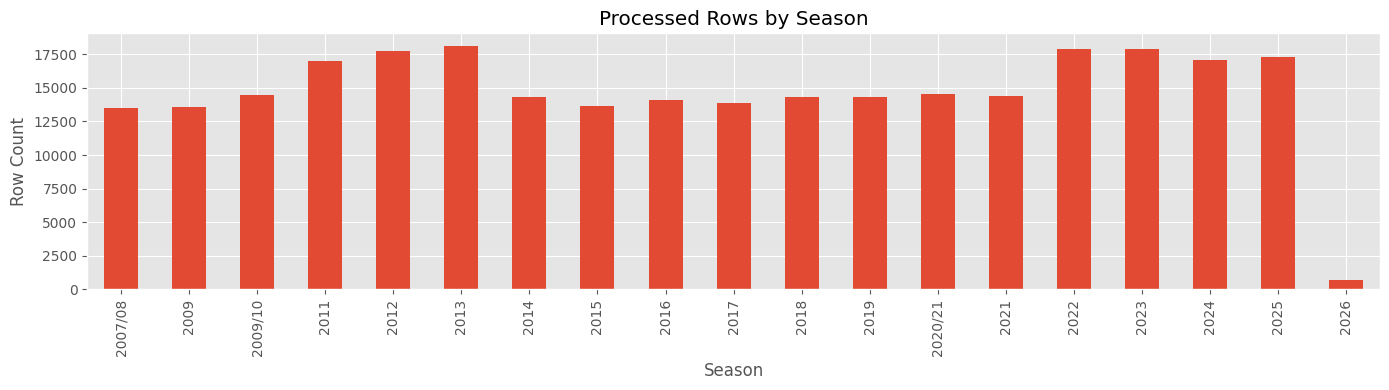

In [8]:
ax = season_counts.plot(kind='bar', figsize=(14, 4), title='Processed Rows by Season')
ax.set_xlabel('Season')
ax.set_ylabel('Row Count')
plt.tight_layout()

## Team and Venue Coverage

In [9]:
top_batting = df['batting_team'].value_counts().head(15)
top_bowling = df['bowling_team'].value_counts().head(15)
top_venues = df['venue'].value_counts().head(15)

display(top_batting.to_frame('batting_rows'))
display(top_bowling.to_frame('bowling_rows'))
display(top_venues.to_frame('venue_rows'))

,batting_rows
batting_team,
Mumbai Indians,33414
Royal Challengers Bengaluru,31819
Punjab Kings,31487
Delhi Capitals,31376
Kolkata Knight Riders,31000
Chennai Super Kings,30515
Rajasthan Royals,27976
Sunrisers Hyderabad,23546
Deccan Chargers,9034


,bowling_rows
bowling_team,
Mumbai Indians,33527
Royal Challengers Bengaluru,32001
Delhi Capitals,31584
Kolkata Knight Riders,31269
Punjab Kings,31042
Chennai Super Kings,30281
Rajasthan Royals,28295
Sunrisers Hyderabad,23434
Deccan Chargers,9039


,venue_rows
venue,
Wankhede Stadium,30378
Eden Gardens,23436
Arun Jaitley Stadium,22971
MA Chidambaram Stadium,22111
M. Chinnaswamy Stadium,19669
Rajiv Gandhi International Stadium,15200
Sawai Mansingh Stadium,15194
Punjab Cricket Association Stadium,13269
Dubai International Cricket Stadium,11187


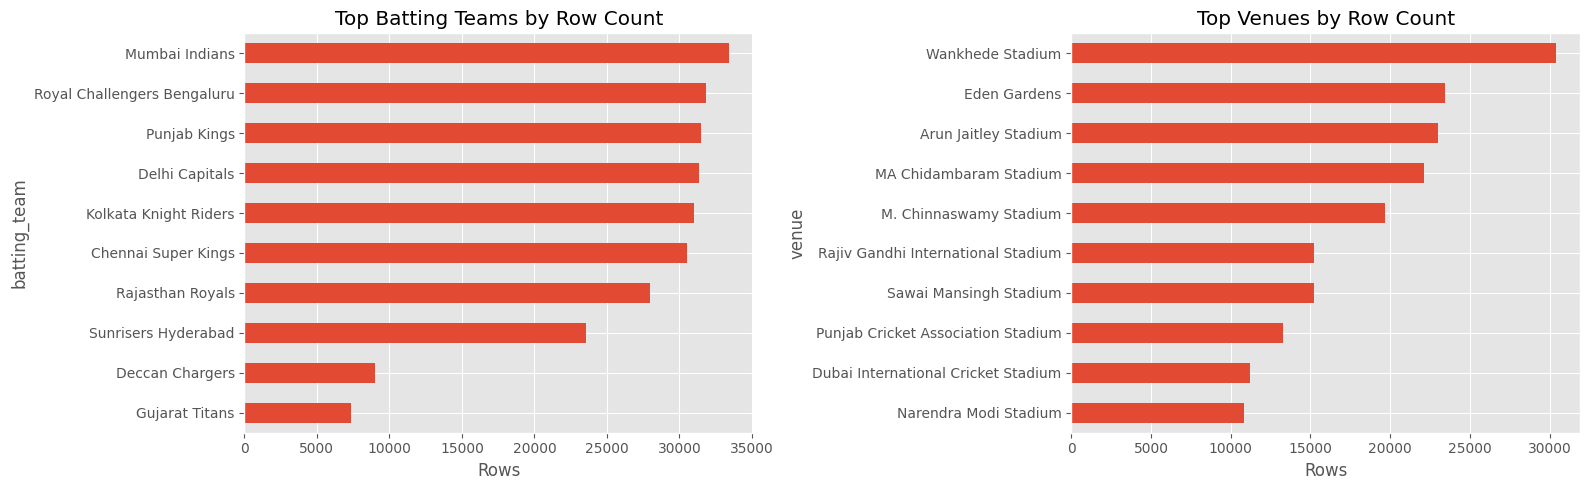

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
top_batting.head(10).sort_values().plot(kind='barh', ax=axes[0], title='Top Batting Teams by Row Count')
top_venues.head(10).sort_values().plot(kind='barh', ax=axes[1], title='Top Venues by Row Count')
axes[0].set_xlabel('Rows')
axes[1].set_xlabel('Rows')
plt.tight_layout()

## Innings and Phase Structure

In [11]:
innings_counts = df['innings'].value_counts().sort_index()
phase_counts = df['phase'].value_counts()
display(innings_counts.to_frame('rows'))
display(phase_counts.to_frame('rows'))

,rows
innings,
1,144508
2,134197


,rows
phase,
middle,127886
powerplay,87500
death,63319


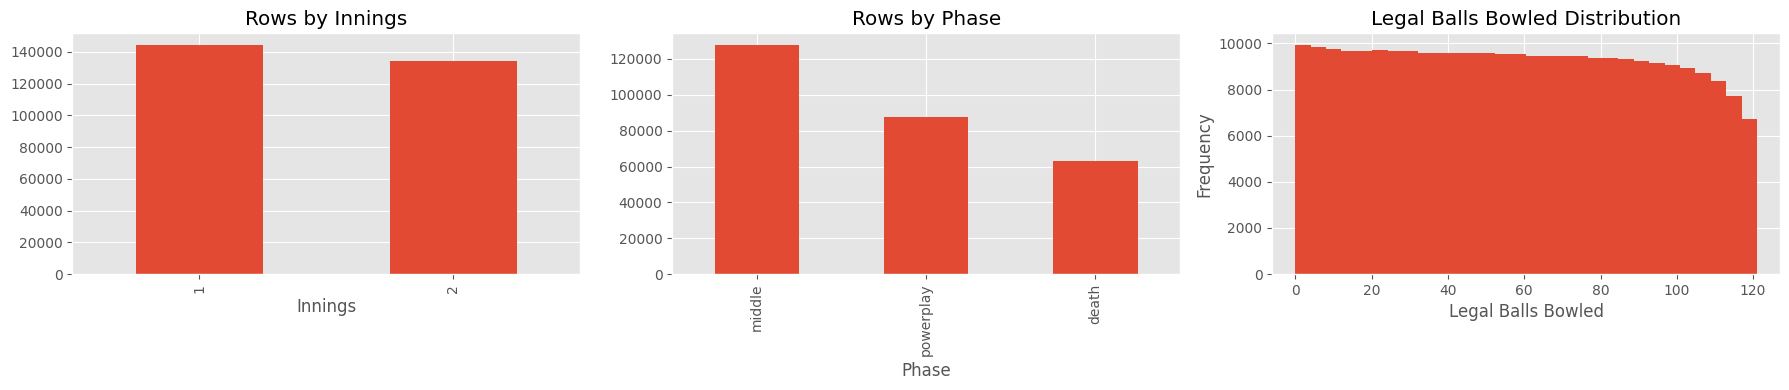

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
innings_counts.plot(kind='bar', ax=axes[0], title='Rows by Innings')
phase_counts.plot(kind='bar', ax=axes[1], title='Rows by Phase')
df['legal_balls_bowled'].plot(kind='hist', bins=30, ax=axes[2], title='Legal Balls Bowled Distribution')
axes[0].set_xlabel('Innings')
axes[1].set_xlabel('Phase')
axes[2].set_xlabel('Legal Balls Bowled')
plt.tight_layout()

## Numeric Distributions

In [13]:
df[['runs', 'wickets', 'balls_left', 'current_run_rate', 'total_runs']].describe().T

,count,mean,std,min,25%,50%,75%,max
runs,"278,705.000",77.197,49.976,0.000,36.000,73.000,114.000,287.000
wickets,"278,705.000",2.462,2.103,0.000,1.000,2.000,4.000,10.000
balls_left,"278,705.000",61.359,34.098,0.000,32.000,62.000,91.000,120.000
current_run_rate,"278,705.000",7.664,2.429,0.000,6.389,7.660,8.936,66.000
total_runs,"278,705.000",162.258,32.038,2.000,141.000,162.000,183.000,287.000


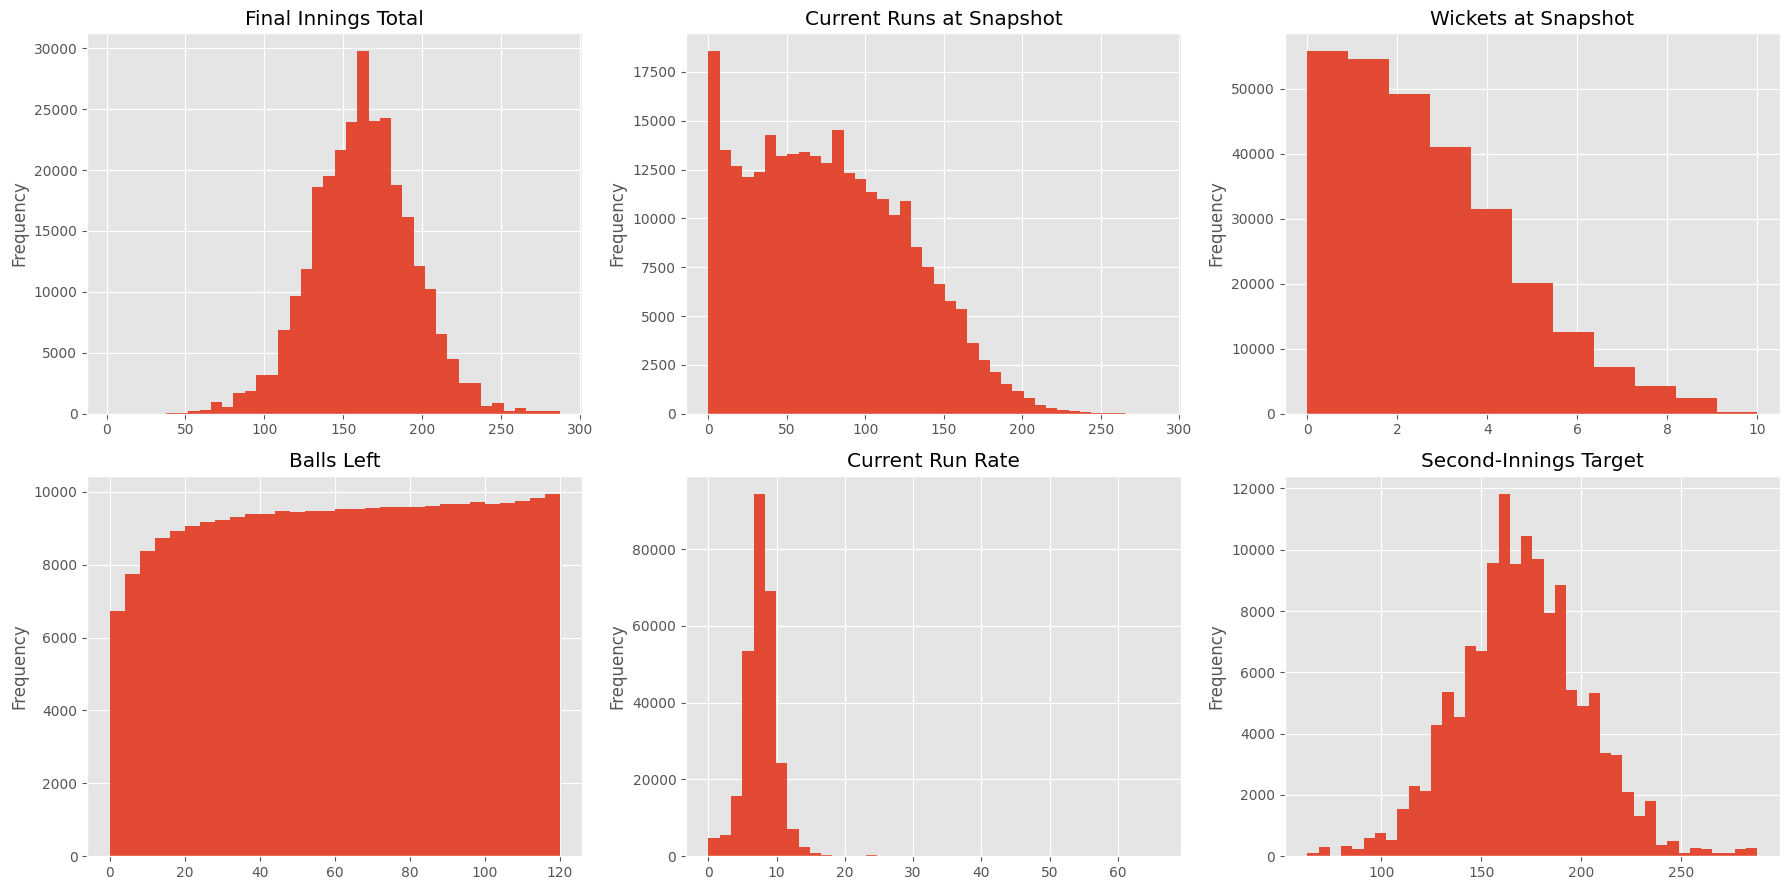

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
df['total_runs'].plot(kind='hist', bins=40, ax=axes[0, 0], title='Final Innings Total')
df['runs'].plot(kind='hist', bins=40, ax=axes[0, 1], title='Current Runs at Snapshot')
df['wickets'].plot(kind='hist', bins=11, ax=axes[0, 2], title='Wickets at Snapshot')
df['balls_left'].plot(kind='hist', bins=30, ax=axes[1, 0], title='Balls Left')
df['current_run_rate'].plot(kind='hist', bins=40, ax=axes[1, 1], title='Current Run Rate')
df['target'].dropna().plot(kind='hist', bins=40, ax=axes[1, 2], title='Second-Innings Target')
plt.tight_layout()

## First vs Second Innings Summary

In [15]:
innings_summary = (
    df.groupby('innings')
    .agg(
        rows=('match_id', 'size'),
        mean_total_runs=('total_runs', 'mean'),
        mean_runs_at_snapshot=('runs', 'mean'),
        mean_wickets=('wickets', 'mean'),
        mean_current_rr=('current_run_rate', 'mean'),
        mean_win=('win', 'mean'),
    )
)
innings_summary

,rows,mean_total_runs,mean_runs_at_snapshot,mean_wickets,mean_current_rr,mean_win
innings,,,,,,
1,144508,167.884,78.945,2.439,7.588,0.460
2,134197,156.201,75.315,2.487,7.747,0.521


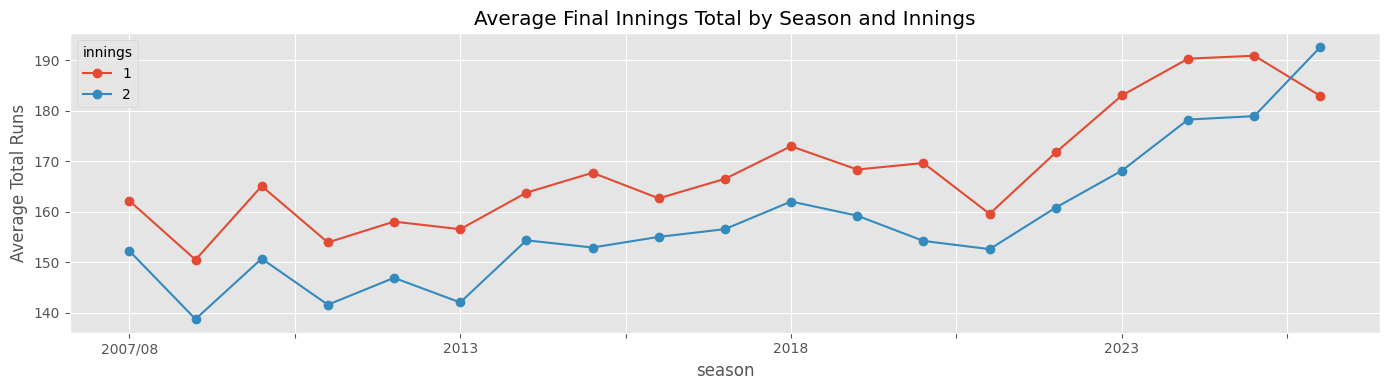

In [16]:
season_innings = df.groupby(['season', 'innings'])['total_runs'].mean().unstack()
season_innings.plot(figsize=(14, 4), marker='o', title='Average Final Innings Total by Season and Innings')
plt.ylabel('Average Total Runs')
plt.tight_layout()

## Win-Rate Analysis

In [17]:
win_summary = pd.Series({
    'non_null_win_rows': len(win_df),
    'overall_batting_team_win_rate': win_df['win'].mean(),
    'first_innings_win_rate': win_df.loc[win_df['innings'] == 1, 'win'].mean(),
    'second_innings_win_rate': win_df.loc[win_df['innings'] == 2, 'win'].mean(),
})
win_summary

non_null_win_rows               274,174.000
overall_batting_team_win_rate         0.489
first_innings_win_rate                0.460
second_innings_win_rate               0.521
dtype: float64

In [18]:
win_by_phase = (
    win_df.groupby('phase')
    .agg(win_rate=('win', 'mean'), rows=('win', 'size'))
    .sort_values('win_rate', ascending=False)
)
win_by_phase

,win_rate,rows
phase,,
powerplay,0.500,86052
middle,0.496,125897
death,0.461,62225


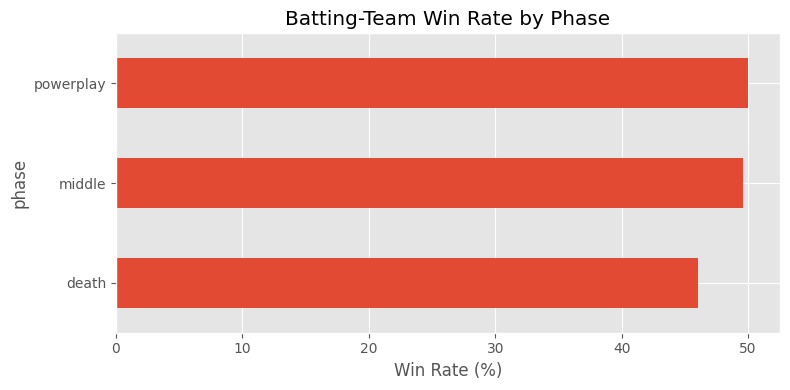

In [19]:
ax = (100 * win_by_phase['win_rate']).sort_values().plot(kind='barh', figsize=(8, 4), title='Batting-Team Win Rate by Phase')
ax.set_xlabel('Win Rate (%)')
plt.tight_layout()

In [20]:
team_win = (
    win_df.groupby('batting_team')
    .agg(win_rate=('win', 'mean'), rows=('win', 'size'))
    .query('rows >= 5000')
    .sort_values('win_rate', ascending=False)
)
team_win

,win_rate,rows
batting_team,,
Gujarat Titans,0.609,7331
Chennai Super Kings,0.559,30387
Mumbai Indians,0.544,32925
Lucknow Super Giants,0.527,7026
Kolkata Knight Riders,0.505,30491
Rajasthan Royals,0.491,27457
Royal Challengers Bengaluru,0.489,31285
Sunrisers Hyderabad,0.470,23051
Punjab Kings,0.450,30812


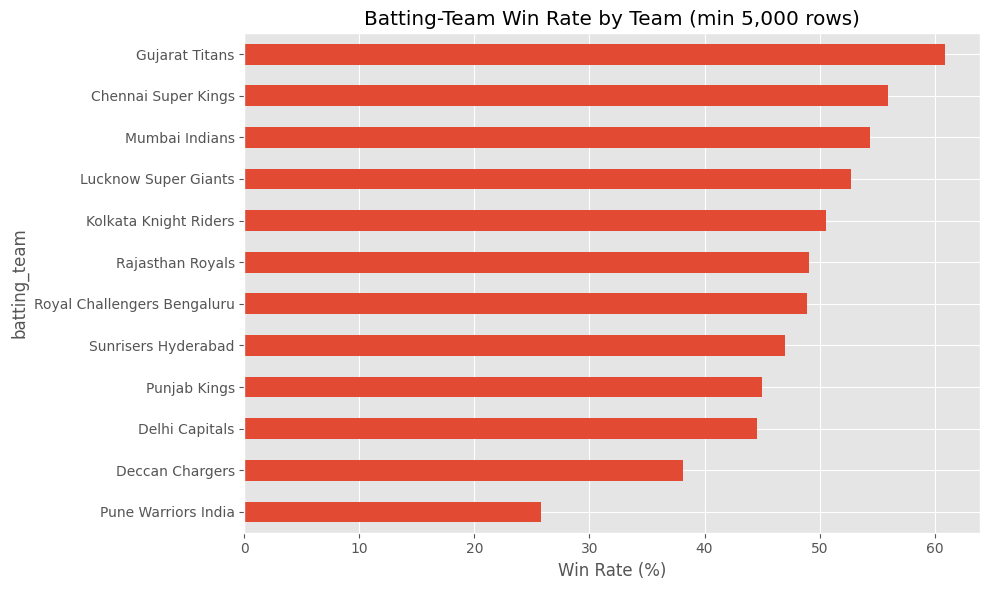

In [21]:
ax = (100 * team_win['win_rate']).sort_values().plot(kind='barh', figsize=(10, 6), title='Batting-Team Win Rate by Team (min 5,000 rows)')
ax.set_xlabel('Win Rate (%)')
plt.tight_layout()

In [22]:
venue_win = (
    win_df.groupby('venue')
    .agg(win_rate=('win', 'mean'), rows=('win', 'size'))
    .query('rows >= 3000')
    .sort_values('win_rate', ascending=False)
)
venue_win.head(15)

,win_rate,rows
venue,,
HPCA Stadium,0.504,3394
ACA-VDCA Stadium,0.502,4000
Maharashtra Cricket Association Stadium,0.501,8414
M.Chinnaswamy Stadium,0.497,3443
Dubai International Cricket Stadium,0.494,10444
MA Chidambaram Stadium,0.493,21613
Sawai Mansingh Stadium,0.491,15194
DY Patil Stadium,0.491,8898
Arun Jaitley Stadium,0.490,22409


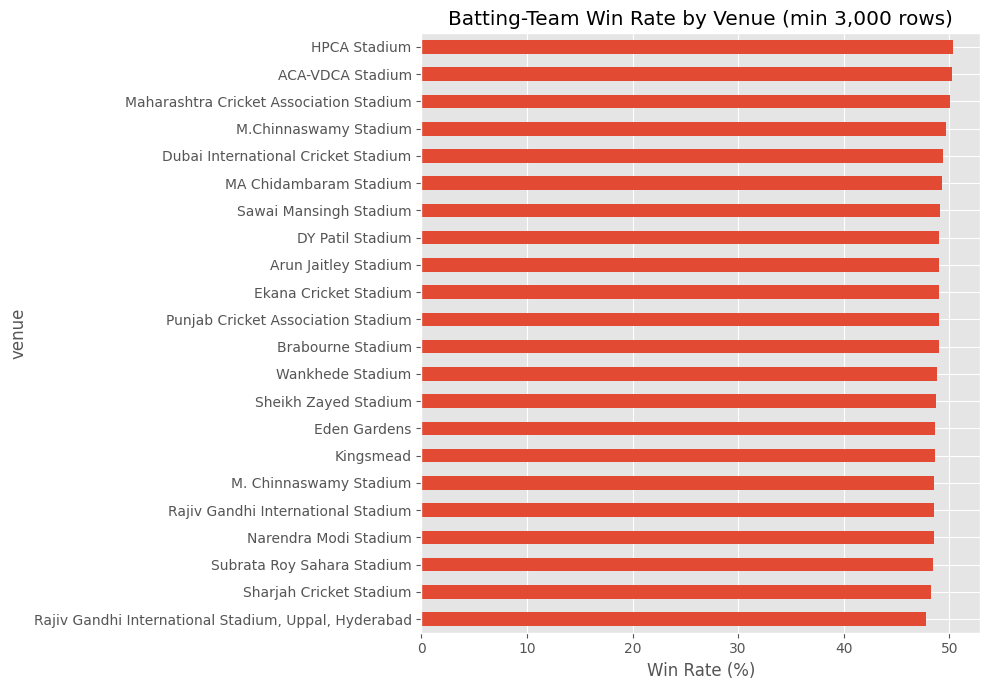

In [23]:
ax = (100 * venue_win['win_rate']).sort_values().plot(kind='barh', figsize=(10, 7), title='Batting-Team Win Rate by Venue (min 3,000 rows)')
ax.set_xlabel('Win Rate (%)')
plt.tight_layout()

In [24]:
phase_team_win = (
    win_df.groupby(['phase', 'batting_team'])
    .agg(win_rate=('win', 'mean'), rows=('win', 'size'))
    .reset_index()
)
phase_team_win = phase_team_win[phase_team_win['rows'] >= 800]
phase_team_pivot = phase_team_win.pivot(index='batting_team', columns='phase', values='win_rate')
phase_team_pivot

phase,death,middle,powerplay
batting_team,,,
Chennai Super Kings,0.541,0.565,0.565
Deccan Chargers,0.371,0.382,0.390
Delhi Capitals,0.413,0.454,0.458
Gujarat Lions,NaN,0.441,0.453
Gujarat Titans,0.593,0.614,0.613
Kolkata Knight Riders,0.467,0.513,0.520
Lucknow Super Giants,0.527,0.530,0.523
Mumbai Indians,0.515,0.550,0.555
Pune Warriors India,0.232,0.266,0.267


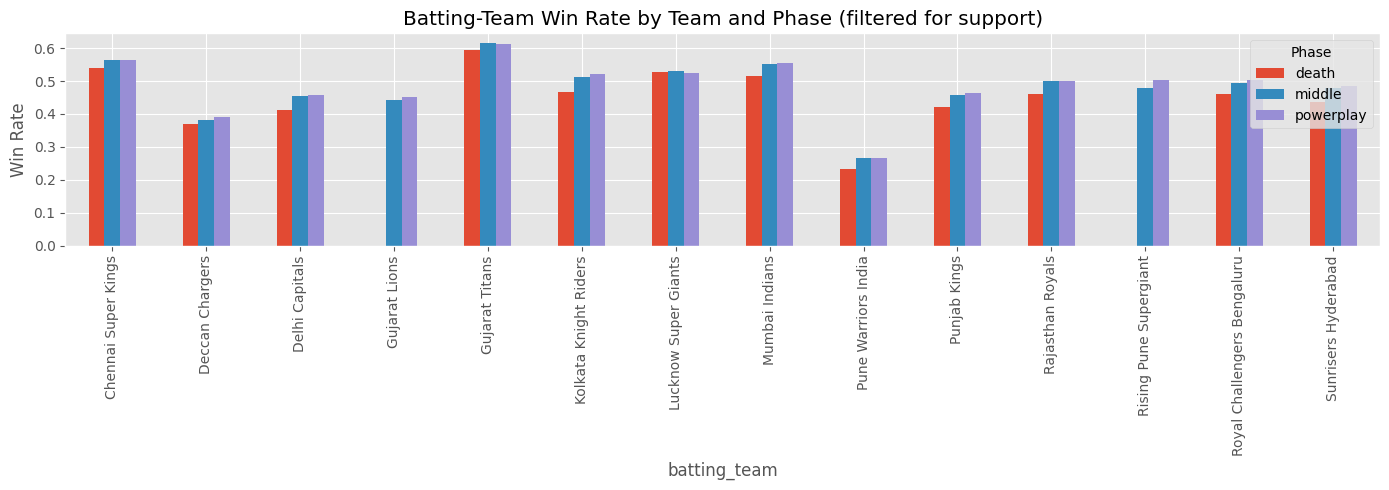

In [25]:
ax = phase_team_pivot.plot(kind='bar', figsize=(14, 5), title='Batting-Team Win Rate by Team and Phase (filtered for support)')
ax.set_ylabel('Win Rate')
plt.legend(title='Phase')
plt.tight_layout()

## Correlation Snapshot

In [26]:
corr_cols = [
    'runs', 'wickets', 'balls_left', 'innings_progress', 'current_run_rate',
    'target_remaining', 'required_run_rate', 'required_minus_current_rr',
    'runs_vs_par', 'total_runs'
]
corr = df[corr_cols].corr(numeric_only=True)
corr['total_runs'].sort_values(ascending=False)

total_runs                   1.000
current_run_rate             0.453
runs_vs_par                  0.417
runs                         0.289
target_remaining             0.154
innings_progress             0.058
required_run_rate            0.058
required_minus_current_rr   -0.017
balls_left                  -0.058
wickets                     -0.186
Name: total_runs, dtype: float64

## Quick Findings

In [27]:
findings = [
    f"Processed dataset has {len(df):,} rows across {df['match_id'].nunique():,} matches.",
    f"Coverage runs from {df['start_date'].min().date()} to {df['start_date'].max().date()}.",
    f"Average final innings total is {df['total_runs'].mean():.2f}; average chase target is {df['target'].dropna().mean():.2f}.",
    f"Batting-team win rate across non-null rows is {100 * win_df['win'].mean():.2f}%.",
    f"First-innings batting-side win rate is {100 * win_df.loc[win_df['innings'] == 1, 'win'].mean():.2f}%.",
    f"Second-innings batting-side win rate is {100 * win_df.loc[win_df['innings'] == 2, 'win'].mean():.2f}%.",
]
pd.Series(findings, name='summary')

0    Processed dataset has 278,705 rows across 1,17...
1         Coverage runs from 2008-04-18 to 2026-03-30.
2    Average final innings total is 162.26; average...
3    Batting-team win rate across non-null rows is ...
4       First-innings batting-side win rate is 45.97%.
5      Second-innings batting-side win rate is 52.08%.
Name: summary, dtype: object